## System parameter definition

Our DDR system requires to set the following paramters:
- $dt$ the sampling time to update the main loop
- $axle\_length$ the distance between the two wheels
- $lamda\_$ the conversion factor from the Thymio speed to $mm/s$

### Sampling time $dt$

In order to define the *Extended Kalman Filter* sampling time $dt$, we looked into the effective sampling rates of the Thymio robot’s sensors and we obtain the following list:
- Motors variables update - $100 \ Hz$

- Camera frame update - $30 \ Hz$

- Proximity sensors update - $10 \ Hz$

However, although the motor control loop is specified in the datasheet as running at 100 Hz, we discovered that the speed sensing subsystem does not provide new measurements at this rate. By logging sensor values while attempting to read the motor speed at 100 Hz, we observed that the returned values remained constant for blocks of approximately ten consecutive samples before changing. This indicates that the robot internally updates its speed estimation only at 10 Hz, which is consistent with the documented update rate of the infrared proximity sensors.

In other words, even though the motors themselves can be driven at 100 Hz, the measured odometry information is effectively limited to 10 Hz. 

Hence we have decided to define $dt = 0.1 \ s$.

In [78]:
from tdmclient import ClientAsync, aw
client = ClientAsync()
node = aw(client.wait_for_node())
aw(node.lock())

Node 31f13e28-c38e-40c7-9b16-7ec0fd554539

In [3]:
from src.utils.speed_variance_calculator import SpeedVarianceCalculator 

tp8_exp = SpeedVarianceCalculator(0.1, 30, 50, 50)

tp8_exp.data = [{'ground': [840, 916], 'sensor': [840, 916], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 912], 'sensor': [832, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [831, 909], 'sensor': [831, 909], 'left_speed': 0, 'right_speed': 0}, {'ground': [831, 911], 'sensor': [831, 911], 'left_speed': 0, 'right_speed': 0}, {'ground': [829, 908], 'sensor': [829, 908], 'left_speed': 0, 'right_speed': 0}, {'ground': [831, 918], 'sensor': [831, 918], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 909], 'sensor': [832, 909], 'left_speed': 0, 'right_speed': 0}, {'ground': [831, 910], 'sensor': [831, 910], 'left_speed': 0, 'right_speed': 0}, {'ground': [830, 911], 'sensor': [830, 911], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 912], 'sensor': [832, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 910], 'sensor': [832, 910], 'left_speed': 0, 'right_speed': 0}, {'ground': [830, 912], 'sensor': [830, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [836, 912], 'sensor': [836, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [840, 912], 'sensor': [840, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [836, 912], 'sensor': [836, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 911], 'sensor': [832, 911], 'left_speed': 0, 'right_speed': 0}, {'ground': [831, 919], 'sensor': [831, 919], 'left_speed': 0, 'right_speed': 0}, {'ground': [833, 912], 'sensor': [833, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [834, 919], 'sensor': [834, 919], 'left_speed': 0, 'right_speed': 0}, {'ground': [835, 912], 'sensor': [835, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [840, 912], 'sensor': [840, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [833, 912], 'sensor': [833, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [834, 916], 'sensor': [834, 916], 'left_speed': 0, 'right_speed': 0}, {'ground': [839, 910], 'sensor': [839, 910], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 911], 'sensor': [832, 911], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 910], 'sensor': [832, 910], 'left_speed': 0, 'right_speed': 0}, {'ground': [835, 911], 'sensor': [835, 911], 'left_speed': 0, 'right_speed': 0}, {'ground': [839, 916], 'sensor': [839, 916], 'left_speed': 0, 'right_speed': 0}, {'ground': [836, 912], 'sensor': [836, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [833, 910], 'sensor': [833, 910], 'left_speed': 0, 'right_speed': 0}, {'ground': [840, 918], 'sensor': [840, 918], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 909], 'sensor': [832, 909], 'left_speed': 0, 'right_speed': 0}, {'ground': [833, 912], 'sensor': [833, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [840, 912], 'sensor': [840, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [831, 912], 'sensor': [831, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 911], 'sensor': [832, 911], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 911], 'sensor': [832, 911], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 910], 'sensor': [832, 910], 'left_speed': 0, 'right_speed': 0}, {'ground': [834, 916], 'sensor': [834, 916], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 911], 'sensor': [832, 911], 'left_speed': 0, 'right_speed': 0}, {'ground': [833, 912], 'sensor': [833, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [836, 912], 'sensor': [836, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [831, 914], 'sensor': [831, 914], 'left_speed': 0, 'right_speed': 0}, {'ground': [835, 911], 'sensor': [835, 911], 'left_speed': 0, 'right_speed': 0}, {'ground': [831, 911], 'sensor': [831, 911], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 911], 'sensor': [832, 911], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 912], 'sensor': [832, 912], 'left_speed': 0, 'right_speed': 0}, {'ground': [839, 909], 'sensor': [839, 909], 'left_speed': 0, 'right_speed': 0}, {'ground': [832, 912], 'sensor': [832, 912], 'left_speed': 27, 'right_speed': 25}, {'ground': [838, 912], 'sensor': [838, 912], 'left_speed': 37, 'right_speed': 37}, {'ground': [844, 923], 'sensor': [844, 923], 'left_speed': 44, 'right_speed': 45}, {'ground': [847, 918], 'sensor': [847, 918], 'left_speed': 46, 'right_speed': 41}, {'ground': [847, 918], 'sensor': [847, 918], 'left_speed': 46, 'right_speed': 41}, {'ground': [854, 918], 'sensor': [854, 918], 'left_speed': 52, 'right_speed': 47}, {'ground': [854, 918], 'sensor': [854, 918], 'left_speed': 51, 'right_speed': 47}, {'ground': [849, 920], 'sensor': [849, 920], 'left_speed': 51, 'right_speed': 47}, {'ground': [834, 919], 'sensor': [834, 919], 'left_speed': 49, 'right_speed': 50}, {'ground': [834, 919], 'sensor': [834, 919], 'left_speed': 49, 'right_speed': 50}, {'ground': [819, 896], 'sensor': [819, 896], 'left_speed': 49, 'right_speed': 52}, {'ground': [721, 738], 'sensor': [721, 738], 'left_speed': 50, 'right_speed': 53}, {'ground': [544, 490], 'sensor': [544, 490], 'left_speed': 52, 'right_speed': 54}, {'ground': [356, 262], 'sensor': [356, 262], 'left_speed': 52, 'right_speed': 54}, {'ground': [176, 128], 'sensor': [176, 128], 'left_speed': 51, 'right_speed': 54}, {'ground': [113, 115], 'sensor': [113, 115], 'left_speed': 51, 'right_speed': 53}, {'ground': [108, 113], 'sensor': [108, 113], 'left_speed': 50, 'right_speed': 52}, {'ground': [101, 111], 'sensor': [101, 111], 'left_speed': 50, 'right_speed': 51}, {'ground': [102, 109], 'sensor': [102, 109], 'left_speed': 49, 'right_speed': 45}, {'ground': [100, 110], 'sensor': [100, 110], 'left_speed': 48, 'right_speed': 50}, {'ground': [101, 119], 'sensor': [101, 119], 'left_speed': 50, 'right_speed': 51}, {'ground': [108, 113], 'sensor': [108, 113], 'left_speed': 50, 'right_speed': 49}, {'ground': [107, 113], 'sensor': [107, 113], 'left_speed': 50, 'right_speed': 49}, {'ground': [107, 116], 'sensor': [107, 116], 'left_speed': 50, 'right_speed': 45}, {'ground': [103, 122], 'sensor': [103, 122], 'left_speed': 50, 'right_speed': 44}, {'ground': [103, 124], 'sensor': [103, 124], 'left_speed': 47, 'right_speed': 44}, {'ground': [103, 119], 'sensor': [103, 119], 'left_speed': 47, 'right_speed': 45}, {'ground': [102, 124], 'sensor': [102, 124], 'left_speed': 48, 'right_speed': 45}, {'ground': [100, 121], 'sensor': [100, 121], 'left_speed': 49, 'right_speed': 45}, {'ground': [102, 112], 'sensor': [102, 112], 'left_speed': 48, 'right_speed': 45}, {'ground': [102, 111], 'sensor': [102, 111], 'left_speed': 50, 'right_speed': 46}, {'ground': [104, 113], 'sensor': [104, 113], 'left_speed': 48, 'right_speed': 46}, {'ground': [105, 112], 'sensor': [105, 112], 'left_speed': 48, 'right_speed': 47}, {'ground': [107, 121], 'sensor': [107, 121], 'left_speed': 50, 'right_speed': 48}, {'ground': [140, 209], 'sensor': [140, 209], 'left_speed': 50, 'right_speed': 50}, {'ground': [256, 382], 'sensor': [256, 382], 'left_speed': 52, 'right_speed': 56}, {'ground': [375, 486], 'sensor': [375, 486], 'left_speed': 54, 'right_speed': 56}, {'ground': [422, 462], 'sensor': [422, 462], 'left_speed': 54, 'right_speed': 59}, {'ground': [380, 325], 'sensor': [380, 325], 'left_speed': 54, 'right_speed': 55}, {'ground': [122, 116], 'sensor': [122, 116], 'left_speed': 54, 'right_speed': 53}, {'ground': [100, 112], 'sensor': [100, 112], 'left_speed': 53, 'right_speed': 52}, {'ground': [100, 110], 'sensor': [100, 110], 'left_speed': 51, 'right_speed': 53}, {'ground': [99, 113], 'sensor': [99, 113], 'left_speed': 48, 'right_speed': 51}, {'ground': [98, 116], 'sensor': [98, 116], 'left_speed': 47, 'right_speed': 48}, {'ground': [97, 117], 'sensor': [97, 117], 'left_speed': 48, 'right_speed': 48}, {'ground': [102, 108], 'sensor': [102, 108], 'left_speed': 48, 'right_speed': 45}, {'ground': [101, 108], 'sensor': [101, 108], 'left_speed': 47, 'right_speed': 43}, {'ground': [101, 105], 'sensor': [101, 105], 'left_speed': 46, 'right_speed': 43}, {'ground': [103, 109], 'sensor': [103, 109], 'left_speed': 46, 'right_speed': 43}, {'ground': [99, 107], 'sensor': [99, 107], 'left_speed': 46, 'right_speed': 45}, {'ground': [102, 108], 'sensor': [102, 108], 'left_speed': 47, 'right_speed': 46}, {'ground': [105, 107], 'sensor': [105, 107], 'left_speed': 48, 'right_speed': 49}, {'ground': [98, 106], 'sensor': [98, 106], 'left_speed': 49, 'right_speed': 48}, {'ground': [93, 101], 'sensor': [93, 101], 'left_speed': 48, 'right_speed': 49}, {'ground': [101, 106], 'sensor': [101, 106], 'left_speed': 52, 'right_speed': 49}, {'ground': [101, 107], 'sensor': [101, 107], 'left_speed': 52, 'right_speed': 51}, {'ground': [99, 111], 'sensor': [99, 111], 'left_speed': 53, 'right_speed': 52}, {'ground': [104, 110], 'sensor': [104, 110], 'left_speed': 52, 'right_speed': 55}, {'ground': [114, 161], 'sensor': [114, 161], 'left_speed': 53, 'right_speed': 56}, {'ground': [170, 295], 'sensor': [170, 295], 'left_speed': 54, 'right_speed': 55}, {'ground': [319, 468], 'sensor': [319, 468], 'left_speed': 53, 'right_speed': 54}, {'ground': [446, 570], 'sensor': [446, 570], 'left_speed': 51, 'right_speed': 51}, {'ground': [528, 592], 'sensor': [528, 592], 'left_speed': 50, 'right_speed': 49}, {'ground': [511, 496], 'sensor': [511, 496], 'left_speed': 49, 'right_speed': 48}, {'ground': [424, 420], 'sensor': [424, 420], 'left_speed': 49, 'right_speed': 45}, {'ground': [383, 404], 'sensor': [383, 404], 'left_speed': 47, 'right_speed': 44}, {'ground': [373, 406], 'sensor': [373, 406], 'left_speed': 46, 'right_speed': 42}, {'ground': [375, 407], 'sensor': [375, 407], 'left_speed': 46, 'right_speed': 43}, {'ground': [367, 408], 'sensor': [367, 408], 'left_speed': 46, 'right_speed': 43}, {'ground': [366, 411], 'sensor': [366, 411], 'left_speed': 47, 'right_speed': 44}, {'ground': [363, 412], 'sensor': [363, 412], 'left_speed': 48, 'right_speed': 48}, {'ground': [365, 412], 'sensor': [365, 412], 'left_speed': 49, 'right_speed': 50}, {'ground': [369, 415], 'sensor': [369, 415], 'left_speed': 50, 'right_speed': 51}, {'ground': [371, 415], 'sensor': [371, 415], 'left_speed': 52, 'right_speed': 52}, {'ground': [368, 416], 'sensor': [368, 416], 'left_speed': 52, 'right_speed': 56}, {'ground': [370, 414], 'sensor': [370, 414], 'left_speed': 53, 'right_speed': 57}, {'ground': [371, 411], 'sensor': [371, 411], 'left_speed': 56, 'right_speed': 56}, {'ground': [367, 410], 'sensor': [367, 410], 'left_speed': 56, 'right_speed': 57}, {'ground': [363, 414], 'sensor': [363, 414], 'left_speed': 51, 'right_speed': 51}, {'ground': [368, 411], 'sensor': [368, 411], 'left_speed': 51, 'right_speed': 51}, {'ground': [373, 411], 'sensor': [373, 411], 'left_speed': 49, 'right_speed': 49}, {'ground': [375, 416], 'sensor': [375, 416], 'left_speed': 48, 'right_speed': 47}, {'ground': [380, 426], 'sensor': [380, 426], 'left_speed': 48, 'right_speed': 45}, {'ground': [389, 473], 'sensor': [389, 473], 'left_speed': 46, 'right_speed': 44}, {'ground': [454, 578], 'sensor': [454, 578], 'left_speed': 45, 'right_speed': 43}, {'ground': [555, 656], 'sensor': [555, 656], 'left_speed': 46, 'right_speed': 43}, {'ground': [571, 550], 'sensor': [571, 550], 'left_speed': 44, 'right_speed': 43}, {'ground': [472, 449], 'sensor': [472, 449], 'left_speed': 45, 'right_speed': 43}, {'ground': [403, 420], 'sensor': [403, 420], 'left_speed': 44, 'right_speed': 42}, {'ground': [386, 418], 'sensor': [386, 418], 'left_speed': 46, 'right_speed': 48}, {'ground': [376, 416], 'sensor': [376, 416], 'left_speed': 47, 'right_speed': 48}, {'ground': [372, 413], 'sensor': [372, 413], 'left_speed': 48, 'right_speed': 48}, {'ground': [372, 413], 'sensor': [372, 413], 'left_speed': 49, 'right_speed': 48}, {'ground': [377, 416], 'sensor': [377, 416], 'left_speed': 49, 'right_speed': 50}, {'ground': [376, 417], 'sensor': [376, 417], 'left_speed': 52, 'right_speed': 50}, {'ground': [380, 416], 'sensor': [380, 416], 'left_speed': 51, 'right_speed': 52}, {'ground': [383, 422], 'sensor': [383, 422], 'left_speed': 51, 'right_speed': 54}, {'ground': [388, 418], 'sensor': [388, 418], 'left_speed': 53, 'right_speed': 57}, {'ground': [388, 421], 'sensor': [388, 421], 'left_speed': 53, 'right_speed': 56}, {'ground': [388, 427], 'sensor': [388, 427], 'left_speed': 52, 'right_speed': 57}, {'ground': [389, 428], 'sensor': [389, 428], 'left_speed': 53, 'right_speed': 56}, {'ground': [389, 427], 'sensor': [389, 427], 'left_speed': 53, 'right_speed': 57}, {'ground': [387, 421], 'sensor': [387, 421], 'left_speed': 53, 'right_speed': 57}, {'ground': [382, 413], 'sensor': [382, 413], 'left_speed': 54, 'right_speed': 57}, {'ground': [369, 405], 'sensor': [369, 405], 'left_speed': 52, 'right_speed': 50}, {'ground': [360, 399], 'sensor': [360, 399], 'left_speed': 51, 'right_speed': 46}, {'ground': [349, 398], 'sensor': [349, 398], 'left_speed': 48, 'right_speed': 44}, {'ground': [359, 452], 'sensor': [359, 452], 'left_speed': 47, 'right_speed': 43}, {'ground': [422, 548], 'sensor': [422, 548], 'left_speed': 44, 'right_speed': 43}, {'ground': [422, 548], 'sensor': [422, 548], 'left_speed': 44, 'right_speed': 43}, {'ground': [516, 587], 'sensor': [516, 587], 'left_speed': 45, 'right_speed': 44}, {'ground': [511, 475], 'sensor': [511, 475], 'left_speed': 43, 'right_speed': 43}, {'ground': [389, 289], 'sensor': [389, 289], 'left_speed': 44, 'right_speed': 43}, {'ground': [224, 150], 'sensor': [224, 150], 'left_speed': 45, 'right_speed': 44}, {'ground': [131, 120], 'sensor': [131, 120], 'left_speed': 47, 'right_speed': 44}, {'ground': [112, 115], 'sensor': [112, 115], 'left_speed': 49, 'right_speed': 46}, {'ground': [97, 108], 'sensor': [97, 108], 'left_speed': 49, 'right_speed': 49}, {'ground': [97, 109], 'sensor': [97, 109], 'left_speed': 52, 'right_speed': 52}, {'ground': [95, 112], 'sensor': [95, 112], 'left_speed': 51, 'right_speed': 54}, {'ground': [96, 116], 'sensor': [96, 116], 'left_speed': 54, 'right_speed': 56}, {'ground': [97, 121], 'sensor': [97, 121], 'left_speed': 53, 'right_speed': 56}, {'ground': [99, 126], 'sensor': [99, 126], 'left_speed': 54, 'right_speed': 56}, {'ground': [102, 123], 'sensor': [102, 123], 'left_speed': 53, 'right_speed': 53}, {'ground': [103, 122], 'sensor': [103, 122], 'left_speed': 51, 'right_speed': 52}, {'ground': [103, 122], 'sensor': [103, 122], 'left_speed': 49, 'right_speed': 49}, {'ground': [103, 128], 'sensor': [103, 128], 'left_speed': 48, 'right_speed': 47}, {'ground': [106, 128], 'sensor': [106, 128], 'left_speed': 49, 'right_speed': 45}, {'ground': [103, 126], 'sensor': [103, 126], 'left_speed': 46, 'right_speed': 44}, {'ground': [99, 127], 'sensor': [99, 127], 'left_speed': 46, 'right_speed': 43}, {'ground': [97, 118], 'sensor': [97, 118], 'left_speed': 45, 'right_speed': 43}, {'ground': [100, 120], 'sensor': [100, 120], 'left_speed': 48, 'right_speed': 47}, {'ground': [95, 119], 'sensor': [95, 119], 'left_speed': 50, 'right_speed': 51}, {'ground': [90, 120], 'sensor': [90, 120], 'left_speed': 51, 'right_speed': 52}, {'ground': [94, 134], 'sensor': [94, 134], 'left_speed': 54, 'right_speed': 53}, {'ground': [123, 244], 'sensor': [123, 244], 'left_speed': 54, 'right_speed': 57}, {'ground': [267, 425], 'sensor': [267, 425], 'left_speed': 55, 'right_speed': 56}, {'ground': [428, 503], 'sensor': [428, 503], 'left_speed': 53, 'right_speed': 56}, {'ground': [469, 455], 'sensor': [469, 455], 'left_speed': 52, 'right_speed': 57}, {'ground': [384, 286], 'sensor': [384, 286], 'left_speed': 51, 'right_speed': 55}, {'ground': [228, 145], 'sensor': [228, 145], 'left_speed': 51, 'right_speed': 53}, {'ground': [126, 114], 'sensor': [126, 114], 'left_speed': 48, 'right_speed': 49}, {'ground': [96, 114], 'sensor': [96, 114], 'left_speed': 48, 'right_speed': 47}, {'ground': [104, 108], 'sensor': [104, 108], 'left_speed': 48, 'right_speed': 46}, {'ground': [108, 111], 'sensor': [108, 111], 'left_speed': 45, 'right_speed': 45}, {'ground': [104, 117], 'sensor': [104, 117], 'left_speed': 44, 'right_speed': 45}, {'ground': [106, 115], 'sensor': [106, 115], 'left_speed': 45, 'right_speed': 42}, {'ground': [110, 126], 'sensor': [110, 126], 'left_speed': 46, 'right_speed': 42}, {'ground': [107, 118], 'sensor': [107, 118], 'left_speed': 45, 'right_speed': 43}, {'ground': [103, 112], 'sensor': [103, 112], 'left_speed': 45, 'right_speed': 45}, {'ground': [107, 111], 'sensor': [107, 111], 'left_speed': 46, 'right_speed': 49}, {'ground': [104, 111], 'sensor': [104, 111], 'left_speed': 48, 'right_speed': 50}, {'ground': [101, 112], 'sensor': [101, 112], 'left_speed': 50, 'right_speed': 52}, {'ground': [99, 114], 'sensor': [99, 114], 'left_speed': 51, 'right_speed': 50}, {'ground': [98, 111], 'sensor': [98, 111], 'left_speed': 53, 'right_speed': 57}, {'ground': [99, 109], 'sensor': [99, 109], 'left_speed': 54, 'right_speed': 57}, {'ground': [97, 106], 'sensor': [97, 106], 'left_speed': 53, 'right_speed': 56}, {'ground': [98, 113], 'sensor': [98, 113], 'left_speed': 53, 'right_speed': 57}, {'ground': [107, 114], 'sensor': [107, 114], 'left_speed': 53, 'right_speed': 57}, {'ground': [111, 177], 'sensor': [111, 177], 'left_speed': 52, 'right_speed': 57}, {'ground': [185, 324], 'sensor': [185, 324], 'left_speed': 53, 'right_speed': 56}, {'ground': [342, 459], 'sensor': [342, 459], 'left_speed': 52, 'right_speed': 53}, {'ground': [430, 470], 'sensor': [430, 470], 'left_speed': 49, 'right_speed': 53}, {'ground': [432, 368], 'sensor': [432, 368], 'left_speed': 48, 'right_speed': 52}, {'ground': [313, 193], 'sensor': [313, 193], 'left_speed': 49, 'right_speed': 48}, {'ground': [156, 112], 'sensor': [156, 112], 'left_speed': 48, 'right_speed': 45}, {'ground': [105, 109], 'sensor': [105, 109], 'left_speed': 48, 'right_speed': 45}, {'ground': [101, 112], 'sensor': [101, 112], 'left_speed': 48, 'right_speed': 42}, {'ground': [102, 116], 'sensor': [102, 116], 'left_speed': 47, 'right_speed': 43}, {'ground': [98, 114], 'sensor': [98, 114], 'left_speed': 47, 'right_speed': 43}, {'ground': [98, 116], 'sensor': [98, 116], 'left_speed': 47, 'right_speed': 43}, {'ground': [100, 121], 'sensor': [100, 121], 'left_speed': 47, 'right_speed': 44}, {'ground': [102, 121], 'sensor': [102, 121], 'left_speed': 47, 'right_speed': 47}, {'ground': [100, 115], 'sensor': [100, 115], 'left_speed': 50, 'right_speed': 51}, {'ground': [99, 114], 'sensor': [99, 114], 'left_speed': 53, 'right_speed': 53}, {'ground': [101, 113], 'sensor': [101, 113], 'left_speed': 54, 'right_speed': 53}, {'ground': [95, 112], 'sensor': [95, 112], 'left_speed': 55, 'right_speed': 53}, {'ground': [100, 112], 'sensor': [100, 112], 'left_speed': 53, 'right_speed': 52}, {'ground': [100, 109], 'sensor': [100, 109], 'left_speed': 52, 'right_speed': 52}, {'ground': [98, 115], 'sensor': [98, 115], 'left_speed': 51, 'right_speed': 51}, {'ground': [97, 116], 'sensor': [97, 116], 'left_speed': 52, 'right_speed': 51}, {'ground': [98, 106], 'sensor': [98, 106], 'left_speed': 51, 'right_speed': 55}, {'ground': [92, 101], 'sensor': [92, 101], 'left_speed': 54, 'right_speed': 58}, {'ground': [90, 111], 'sensor': [90, 111], 'left_speed': 53, 'right_speed': 56}, {'ground': [93, 145], 'sensor': [93, 145], 'left_speed': 52, 'right_speed': 56}, {'ground': [125, 251], 'sensor': [125, 251], 'left_speed': 50, 'right_speed': 49}, {'ground': [249, 436], 'sensor': [249, 436], 'left_speed': 49, 'right_speed': 45}, {'ground': [411, 544], 'sensor': [411, 544], 'left_speed': 50, 'right_speed': 45}, {'ground': [516, 581], 'sensor': [516, 581], 'left_speed': 48, 'right_speed': 45}, {'ground': [527, 497], 'sensor': [527, 497], 'left_speed': 49, 'right_speed': 44}, {'ground': [441, 412], 'sensor': [441, 412], 'left_speed': 47, 'right_speed': 41}, {'ground': [361, 389], 'sensor': [361, 389], 'left_speed': 47, 'right_speed': 44}, {'ground': [358, 391], 'sensor': [358, 391], 'left_speed': 48, 'right_speed': 43}, {'ground': [353, 392], 'sensor': [353, 392], 'left_speed': 49, 'right_speed': 43}, {'ground': [352, 388], 'sensor': [352, 388], 'left_speed': 48, 'right_speed': 45}, {'ground': [358, 385], 'sensor': [358, 385], 'left_speed': 48, 'right_speed': 47}, {'ground': [356, 384], 'sensor': [356, 384], 'left_speed': 49, 'right_speed': 48}, {'ground': [354, 386], 'sensor': [354, 386], 'left_speed': 49, 'right_speed': 51}, {'ground': [350, 388], 'sensor': [350, 388], 'left_speed': 50, 'right_speed': 53}, {'ground': [351, 386], 'sensor': [351, 386], 'left_speed': 50, 'right_speed': 55}, {'ground': [351, 388], 'sensor': [351, 388], 'left_speed': 52, 'right_speed': 53}, {'ground': [352, 391], 'sensor': [352, 391], 'left_speed': 52, 'right_speed': 50}, {'ground': [352, 391], 'sensor': [352, 391], 'left_speed': 52, 'right_speed': 50}, {'ground': [348, 391], 'sensor': [348, 391], 'left_speed': 49, 'right_speed': 43}, {'ground': [351, 391], 'sensor': [351, 391], 'left_speed': 45, 'right_speed': 43}, {'ground': [352, 391], 'sensor': [352, 391], 'left_speed': 45, 'right_speed': 43}, {'ground': [358, 398], 'sensor': [358, 398], 'left_speed': 45, 'right_speed': 44}, {'ground': [363, 400], 'sensor': [363, 400], 'left_speed': 48, 'right_speed': 48}, {'ground': [367, 407], 'sensor': [367, 407], 'left_speed': 49, 'right_speed': 52}, {'ground': [373, 442], 'sensor': [373, 442], 'left_speed': 52, 'right_speed': 52}, {'ground': [412, 531], 'sensor': [412, 531], 'left_speed': 52, 'right_speed': 57}, {'ground': [511, 675], 'sensor': [511, 675], 'left_speed': 53, 'right_speed': 57}, {'ground': [630, 804], 'sensor': [630, 804], 'left_speed': 54, 'right_speed': 59}, {'ground': [743, 886], 'sensor': [743, 886], 'left_speed': 52, 'right_speed': 57}, {'ground': [743, 886], 'sensor': [743, 886], 'left_speed': 52, 'right_speed': 57}, {'ground': [808, 898], 'sensor': [808, 898], 'left_speed': 53, 'right_speed': 52}, {'ground': [824, 896], 'sensor': [824, 896], 'left_speed': 51, 'right_speed': 50}, {'ground': [825, 900], 'sensor': [825, 900], 'left_speed': 48, 'right_speed': 46}, {'ground': [830, 898], 'sensor': [830, 898], 'left_speed': 44, 'right_speed': 45}, {'ground': [823, 892], 'sensor': [823, 892], 'left_speed': 46, 'right_speed': 43}, {'ground': [808, 848], 'sensor': [808, 848], 'left_speed': 45, 'right_speed': 42}, {'ground': [741, 777], 'sensor': [741, 777], 'left_speed': 44, 'right_speed': 43}, {'ground': [720, 760], 'sensor': [720, 760], 'left_speed': 45, 'right_speed': 44}, {'ground': [708, 760], 'sensor': [708, 760], 'left_speed': 46, 'right_speed': 45}, {'ground': [712, 752], 'sensor': [712, 752], 'left_speed': 48, 'right_speed': 47}, {'ground': [707, 754], 'sensor': [707, 754], 'left_speed': 49, 'right_speed': 51}, {'ground': [711, 754], 'sensor': [711, 754], 'left_speed': 50, 'right_speed': 53}, {'ground': [711, 769], 'sensor': [711, 769], 'left_speed': 55, 'right_speed': 55}, {'ground': [711, 769], 'sensor': [711, 769], 'left_speed': 55, 'right_speed': 55}, {'ground': [715, 789], 'sensor': [715, 789], 'left_speed': 55, 'right_speed': 50}, {'ground': [712, 794], 'sensor': [712, 794], 'left_speed': 54, 'right_speed': 51}, {'ground': [719, 797], 'sensor': [719, 797], 'left_speed': 54, 'right_speed': 48}, {'ground': [719, 799], 'sensor': [719, 799], 'left_speed': 52, 'right_speed': 48}, {'ground': [732, 792], 'sensor': [732, 792], 'left_speed': 46, 'right_speed': 47}, {'ground': [734, 792], 'sensor': [734, 792], 'left_speed': 44, 'right_speed': 47}, {'ground': [733, 785], 'sensor': [733, 785], 'left_speed': 45, 'right_speed': 48}, {'ground': [730, 781], 'sensor': [730, 781], 'left_speed': 51, 'right_speed': 53}, {'ground': [726, 790], 'sensor': [726, 790], 'left_speed': 56, 'right_speed': 54}, {'ground': [728, 786], 'sensor': [728, 786], 'left_speed': 54, 'right_speed': 53}, {'ground': [723, 786], 'sensor': [723, 786], 'left_speed': 52, 'right_speed': 51}, {'ground': [726, 787], 'sensor': [726, 787], 'left_speed': 50, 'right_speed': 48}]

#print(tp8_exp.aquire_data(node, client))

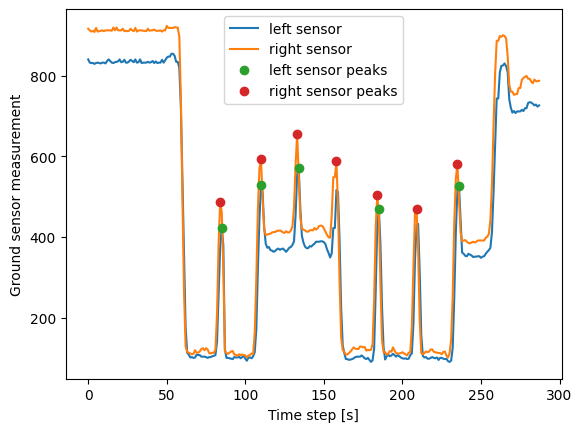

In [4]:
tp8_exp.plot_ground_sensor_detection(400)

In [5]:
tp8_exp.convert_thymio_speed_to_mm_s()

np.float64(0.39735099337748336)

The motor speed covariance in mm^2/s^2 is [[1.88090187 2.38651171]
 [2.38651171 4.11029924]]


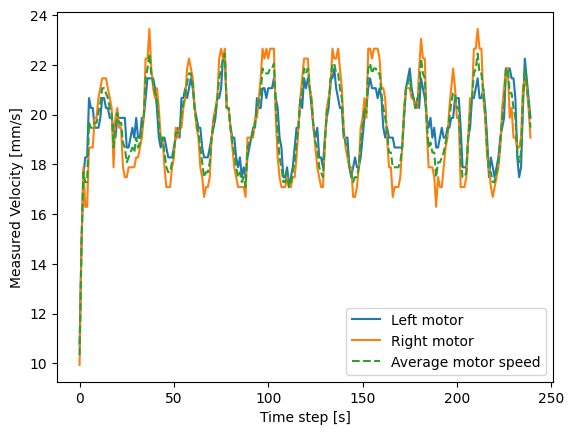

In [6]:
cov = tp8_exp.compute_motor_speed_covariance()
print("The motor speed covariance in mm^2/s^2 is {}".format(cov))

In [7]:
var = tp8_exp.compute_speed_variance(93.5)
print("The speed variance in mm^2/s^2 is {}".format(var))

q_v = r_v = 0.5 * var[0]
q_w = r_w = 0.5 * var[1]

print("The process noise covariance matrix Q is \n{} and \n{}".format(q_v, q_w))
print("The measurement noise covariance matrix R is \n{} and \n{}".format(r_v, r_w))

The speed variance in mm^2/s^2 is (np.float64(2.6910561344020896), np.float64(0.0001393437258884402))
The process noise covariance matrix Q is 
1.3455280672010448 and 
6.96718629442201e-05
The measurement noise covariance matrix R is 
1.3455280672010448 and 
6.96718629442201e-05


In [6]:
aw(node.unlock())

NameError: name 'aw' is not defined

### Axle length measure

With a simple ruler, we have measure the following: $axle\_length = 9.35 \ cm$

### Speed conversion factor

## Test EKF

100%|██████████| 288/288 [00:00<00:00, 20697.35it/s]


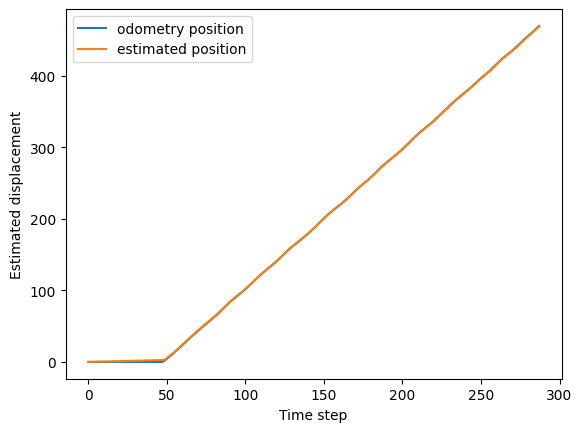

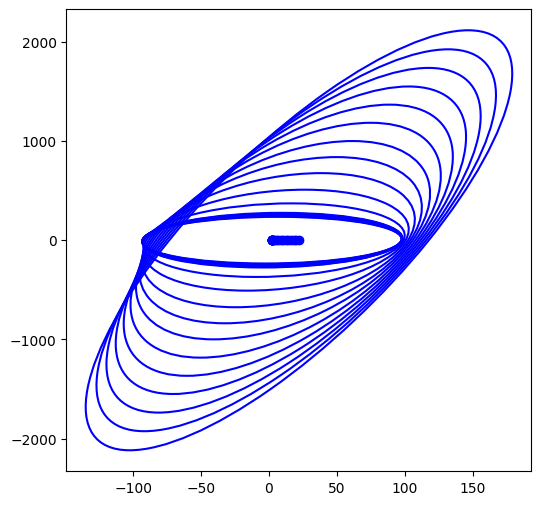

In [16]:
import numpy as np
from src.pose_estimation.extended_kalman_filter import ExtendedKalmanFilter
from src.pose_estimation.differential_drive_system import DifferentialDriveSystem
# Progress bar for loops visualization
from tqdm import tqdm
# Plotting
import matplotlib.pyplot as plt
from src.utils.plot_pose_estimation import *

dt = 0.1
lambda_ = tp8_exp.coef_thymio_speed_to_mm_s  # conversion factor
d = 93.5         # distance between wheels
Q = np.diag([0.01, 0.01, 0.01, q_v, q_w])
R = np.diag([r_v, r_w])

system = DifferentialDriveSystem(dt, lambda_, d, Q, R, True)
    
# Initial state and covariance
mu0 = np.array([0, 0, 0, 0, 0])
Sigma0 = 1000 * np.eye(5)

ekf = ExtendedKalmanFilter(
    mu0, Sigma0,
    system
)

# Example control input and measurement
u = np.array([50, 50])       # v = 0.2 m/s, omega = 0.1 rad/s
x_est = []
P_est = []


for k in tqdm(range(0, len(tp8_exp.data))):
    current_data = tp8_exp.data[k]
    z = np.array([current_data["left_speed"], current_data["right_speed"]])
    new_x_est, new_P_est = ekf.step(u, z)
    x_est.append(new_x_est)
    P_est.append(new_P_est)
    
avg_speed = [(x["left_speed"] + x["right_speed"]) / 2 for x in tp8_exp.data]
pos_increments = avg_speed/(1/(tp8_exp.coef_thymio_speed_to_mm_s*dt))
odom_pos= np.cumsum(pos_increments)
plt.plot([x for x in odom_pos], label="odometry position")
plt.plot([x[0] for x in x_est], label="estimated position")
plt.xlabel("Time step")
plt.ylabel("Estimated displacement")
plt.legend()

fig, ax = plt.subplots(figsize=(6, 6))

for x, P in zip(x_est[40:60], P_est[40:60]):
    plot_state_with_covariance(ax, x, P, n_std=3, color='blue')
